In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [2]:
df = pd.read_csv("../data/processed/telco_clean.csv")

print(df.shape)

df.head()

(7043, 29)


,CustomerID,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Revenue_Per_Month,Tenure_Group,Charge_Group
0,3668-QPYBK,Los Angeles,Male,No,No,No,2,Yes,No,DSL,...,53.85,108.15,Yes,1,86,3239,Competitor made better offer,36.050000,0-1 Year,Medium
1,9237-HQITU,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,...,70.70,151.65,Yes,1,67,2701,Moved,50.550000,0-1 Year,High
2,9305-CDSKC,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,99.65,820.50,Yes,1,86,5372,Moved,91.166667,0-1 Year,Very High
3,7892-POOKP,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,104.80,3046.05,Yes,1,84,5003,Moved,105.036207,2-4 Years,Very High
4,0280-XJGEX,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,103.70,5036.30,Yes,1,89,5340,Competitor had better devices,100.726000,4-6 Years,Very High


In [3]:
segmentation_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV"
]

segment_df = df[segmentation_features].copy()

segment_df.head()

,Tenure Months,Monthly Charges,Total Charges,CLTV
0,2,53.85,108.15,3239
1,2,70.70,151.65,2701
2,8,99.65,820.50,5372
3,28,104.80,3046.05,5003
4,49,103.70,5036.30,5340


In [4]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(segment_df)

scaled_features[:5]

array([[-1.23672422, -0.36266036, -0.95964911, -0.98167549],
       [-1.23672422,  0.19736523, -0.94045745, -1.4364618 ],
       [-0.99240204,  1.1595457 , -0.64536922,  0.82140853],
       [-0.17799476,  1.33071079,  0.33651554,  0.5094826 ],
       [ 0.67713287,  1.29415125,  1.2145889 ,  0.79435804]])

In [6]:



scaled_features = np.nan_to_num(scaled_features)

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)


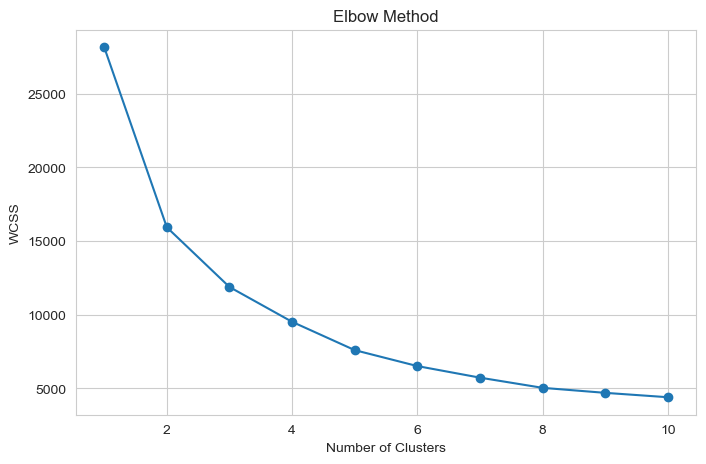

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    scaled_features
)

df["Cluster"] = clusters

In [9]:
df["Cluster"].value_counts()

Cluster
2    2167
1    1949
0    1917
3    1010
Name: count, dtype: int64

In [10]:
cluster_profile = (
    df.groupby("Cluster")
    [
        [
            "Tenure Months",
            "Monthly Charges",
            "Total Charges",
            "CLTV"
        ]
    ]
    .mean()
)

cluster_profile

,Tenure Months,Monthly Charges,Total Charges,CLTV
Cluster,,,,
0,59.173709,93.189280,5505.125222,5100.780386
1,11.026167,57.671575,686.551235,4971.929708
2,17.538994,61.059714,1104.849745,2940.648823
3,54.511881,32.430149,1762.977970,5099.415842


In [11]:
cluster_profile.round(2)

,Tenure Months,Monthly Charges,Total Charges,CLTV
Cluster,,,,
0,59.17,93.19,5505.13,5100.78
1,11.03,57.67,686.55,4971.93
2,17.54,61.06,1104.85,2940.65
3,54.51,32.43,1762.98,5099.42


In [13]:
cluster_names = {
    0:"Champions",
    1:"Loyal Customers",
    2:"At Risk Customers",
    3:"Low Value Customers"
}

df["Customer Segment"] = (
    df["Cluster"]
    .map(cluster_names)
)

In [14]:
df["Customer Segment"].value_counts()


Customer Segment
At Risk Customers      2167
Loyal Customers        1949
Champions              1917
Low Value Customers    1010
Name: count, dtype: int64

In [15]:
segment_churn = pd.crosstab(
    df["Customer Segment"],
    df["Churn Label"],
    normalize="index"
) * 100

segment_churn

Churn Label,No,Yes
Customer Segment,,
At Risk Customers,64.974619,35.025381
Champions,84.194053,15.805947
Low Value Customers,96.039604,3.960396
Loyal Customers,60.646485,39.353515


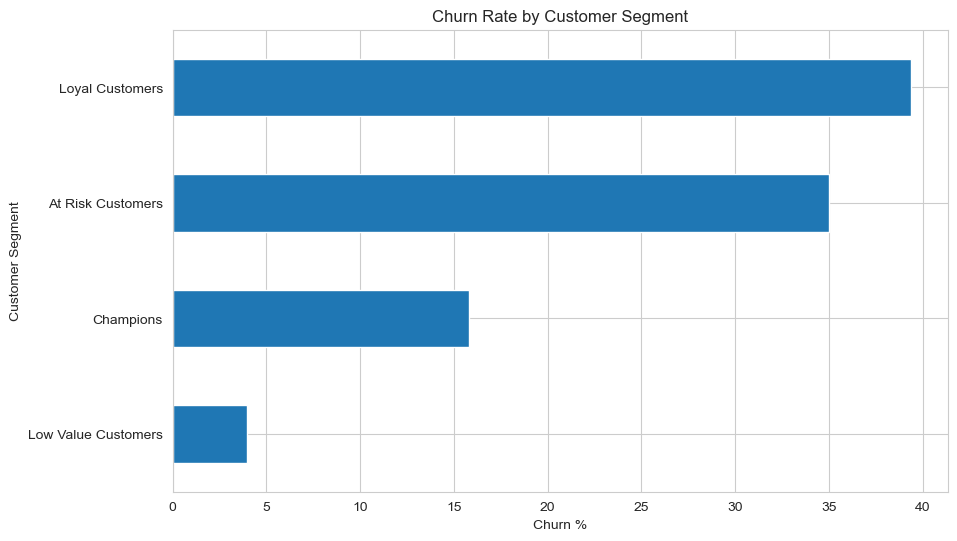

In [16]:
segment_churn["Yes"].sort_values().plot(
    kind="barh"
)

plt.title(
    "Churn Rate by Customer Segment"
)

plt.xlabel("Churn %")

plt.show()

In [17]:
segment_revenue = (
    df.groupby("Customer Segment")
    ["Monthly Charges"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue

Customer Segment
Champions              178643.85
At Risk Customers      132316.40
Loyal Customers        112401.90
Low Value Customers     32754.45
Name: Monthly Charges, dtype: float64

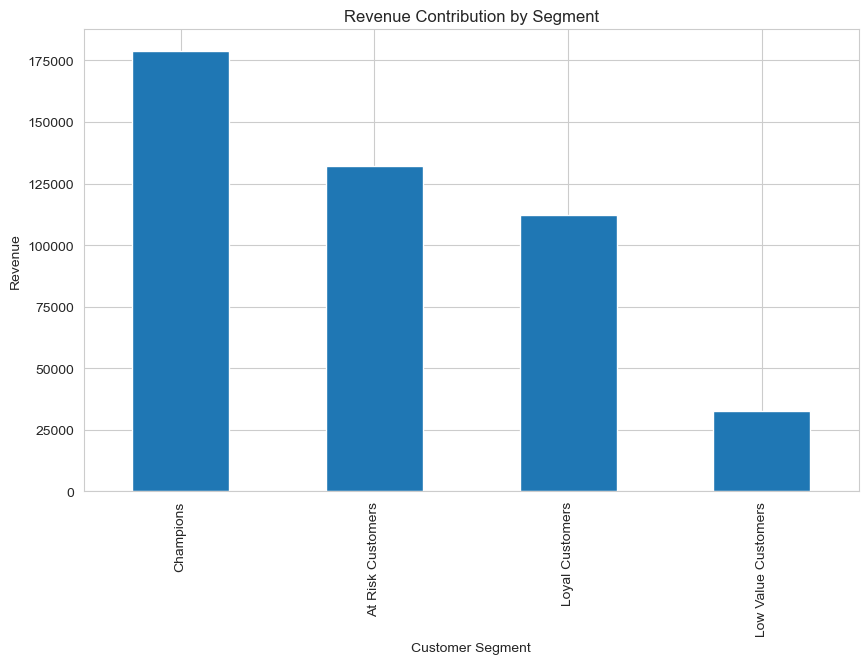

In [18]:
segment_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue Contribution by Segment"
)

plt.ylabel("Revenue")

plt.show()

In [19]:
segment_cltv = (
    df.groupby("Customer Segment")
    ["CLTV"]
    .mean()
)

segment_cltv

Customer Segment
At Risk Customers      2940.648823
Champions              5100.780386
Low Value Customers    5099.415842
Loyal Customers        4971.929708
Name: CLTV, dtype: float64

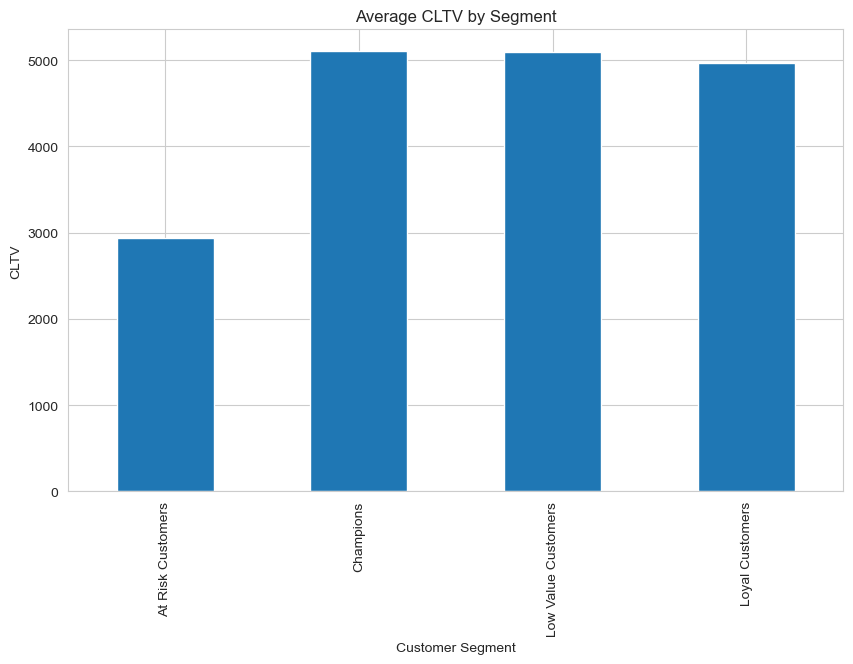

In [20]:
segment_cltv.plot(
    kind="bar"
)

plt.title(
    "Average CLTV by Segment"
)

plt.ylabel("CLTV")

plt.show()

In [21]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

In [22]:
pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = df["Cluster"]

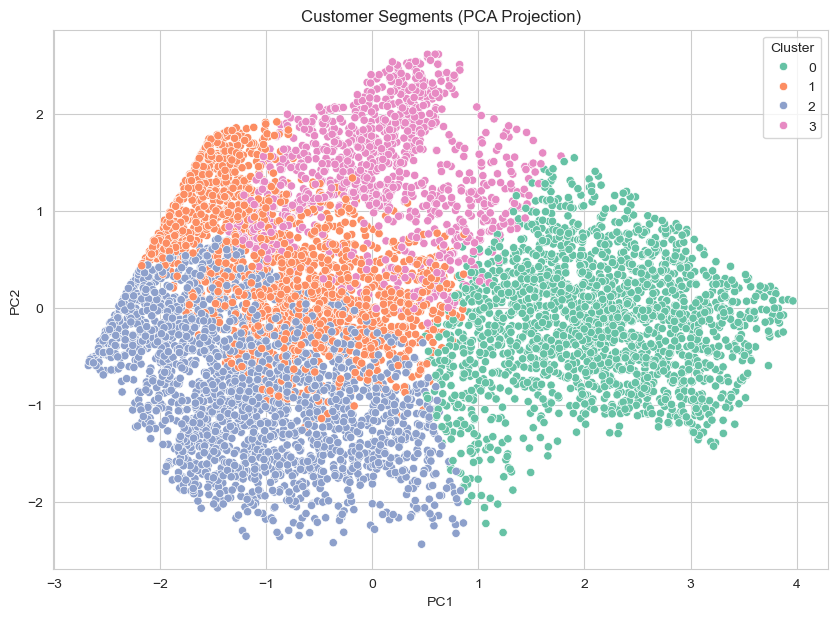

In [23]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title(
    "Customer Segments (PCA Projection)"
)

plt.show()

In [24]:
df.to_csv(
    "../data/processed/telco_segmented.csv",
    index=False
)

print("Segmented dataset saved.")

Segmented dataset saved.


1. Four distinct customer segments were identified using K-Means clustering.

2. At-Risk Customers show the highest churn percentage.

3. Champions contribute the highest customer lifetime value.

4. Loyal Customers generate stable recurring revenue.

5. Retention efforts should focus on high-value customers with elevated churn risk.

6. Segment-based retention campaigns can improve customer lifetime value and reduce revenue loss.